# 01 — A\* Path Planning on an Occupancy Grid

**Section:** Motion Planning · **Mirrors MATLAB:** *Motion Planners (RRT, PRM, Hybrid A\*)*

This notebook implements **A\*** search on a 2-D occupancy grid with 8-connected motion. A\* expands grid cells in order of `f = g + h`, where `g` is the cost-to-come and `h` is the heuristic estimate of cost-to-go.

We use the **Euclidean distance** heuristic, which is admissible (never overestimates) for 8-connected grids with unit-or-√2 edge costs.


## Math

For each cell `n` we keep two numbers:

- `g(n)` — actual cost from the start to `n`
- `h(n)` — heuristic estimate from `n` to the goal: `‖n − goal‖₂`

A\* always expands the node with smallest `f(n) = g(n) + h(n)`. When the goal is popped, the path is optimal (because `h` is admissible).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

np.random.seed(42)


In [2]:
# Build a 30 x 50 occupancy grid with random rectangular obstacles
H, W = 30, 50
grid = np.zeros((H, W), dtype=np.uint8)
for _ in range(40):
    y, x = np.random.randint(2, H - 3), np.random.randint(2, W - 3)
    grid[y - 1:y + 2, x - 1:x + 2] = 1

start = (2, 2)
goal = (H - 3, W - 3)
grid[start] = 0
grid[goal] = 0
print(f"Grid: {H}x{W}, {int(grid.sum())} obstacle cells")


Grid: 30x50, 304 obstacle cells


In [3]:
def astar(grid, start, goal):
    H, W = grid.shape

    def h(a, b):
        return np.hypot(a[0] - b[0], a[1] - b[1])

    open_heap = [(h(start, goal), 0.0, start, None)]
    came_from = {}
    g_score = {start: 0.0}
    nbrs = [(-1, 0), (1, 0), (0, -1), (0, 1),
            (-1, -1), (-1, 1), (1, -1), (1, 1)]

    while open_heap:
        f, g, current, parent = heapq.heappop(open_heap)
        if current in came_from:
            continue
        came_from[current] = parent
        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1], g_score
        for dy, dx in nbrs:
            ny, nx = current[0] + dy, current[1] + dx
            if not (0 <= ny < H and 0 <= nx < W) or grid[ny, nx]:
                continue
            tentative = g + np.hypot(dy, dx)
            neighbor = (ny, nx)
            if tentative < g_score.get(neighbor, np.inf):
                g_score[neighbor] = tentative
                heapq.heappush(
                    open_heap,
                    (tentative + h(neighbor, goal), tentative, neighbor, current),
                )
    return None, g_score


path, g_score = astar(grid, start, goal)
print(f"Path length: {len(path)} cells  ·  expanded {len(g_score)} nodes")


Path length: 47 cells  ·  expanded 522 nodes


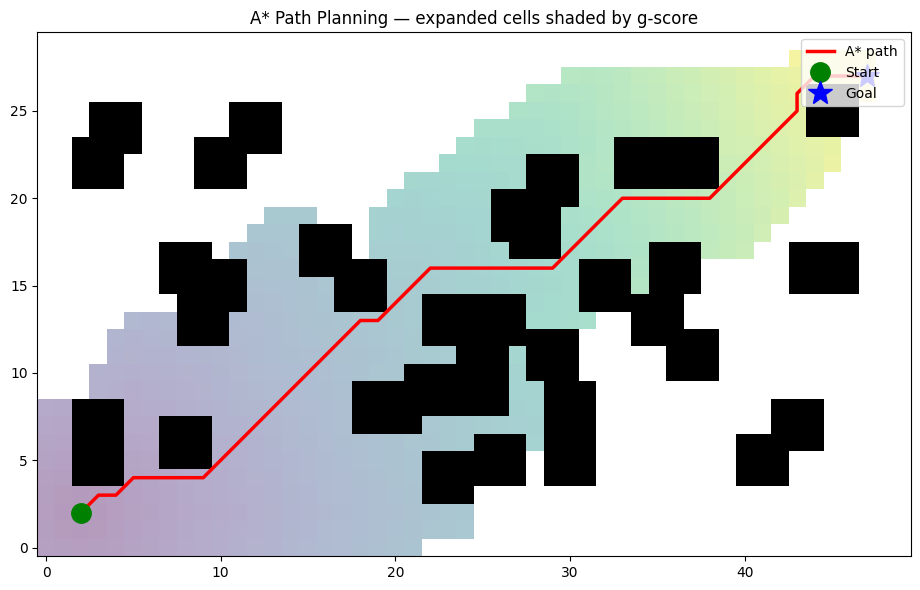

In [4]:
# Visualize
fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(grid, cmap='Greys', origin='lower')

# Heat-map of expanded nodes
expanded = np.full_like(grid, np.nan, dtype=float)
for (y, x), c in g_score.items():
    expanded[y, x] = c
ax.imshow(expanded, cmap='viridis', alpha=0.4, origin='lower')

ys, xs = zip(*path)
ax.plot(xs, ys, 'r-', lw=2.5, label='A* path')
ax.plot(start[1], start[0], 'go', markersize=14, label='Start')
ax.plot(goal[1], goal[0], 'b*', markersize=18, label='Goal')
ax.legend(loc='upper right')
ax.set_title('A* Path Planning — expanded cells shaded by g-score')
plt.tight_layout()
plt.show()


## Extensions

- **D\* / D\* Lite** — incremental replanning when the grid changes (use for dynamic environments).
- **Hybrid A\*** — extends A\* to continuous heading + kinematic constraints (used for car-like robots).
- **Jump Point Search** — a symmetry-breaking optimization for uniform grids; often 10×+ faster than A\*.
